# FEM Pendulum: Contact

In this second tutorial on the FEM implementation of the pendulum, we extend the basic model by introducing a contact between the pendulum head and a wall.

1. **Basics**: We set up the basic model of a deformable pendulum without contact and external torque.
2. **Torque Application**: We extend the basic model by applying an external torque at the pivot point.
3. **Contact Handling** (this tutorial): We further extend the model by adding contact handling with a wall.

Following references were used to implement the model:
- [Nonlinear Elasticity - NGSolve 24](https://docu.ngsolve.org/ngs24/SaS/nonlinearelasticity.html)
- [Elastic Pendulum - NGS Tutorial 2024](https://docu.ngsolve.org/ngs24/tutorials/00_dynamics.html)
- [Contact Problems - NGS Docu Interactive Tutorial](https://docu.ngsolve.org/latest/i-tutorials/unit-6.2-contact/contact.html)
- [An Interactive Introduction to the Finite Element Method, Joachim Schöberl, TU Wien, ASC](https://jschoeberl.github.io/iFEM/intro.html)

```{figure} ../../figures/fem_pendulum.png
---
width: 60%
figclass: caption
alt: fem-pendulum-fig
name: fem-pendulum-fig
---
2D deformable pendulum with wall contact and torque application at the pivot point.
```

## Overview

This tutorial shows how a contact mechanism can be implemented for the pendulum. We will use the basic pendulum with torque application from the previous tutorial.

**Core ideas:**
1. We **add wall** as a second **geometry and material to our mesh**.
2. We define the **boundary conditions** and **adpat the bilinear form accordingly**.
2. We model the contact using a **contact boundary** between the pendulum head and the wall
3. We introduce a **gap function** which will track the gap and penetration of the contact bodies.
4. We use the gap function to **add an energy term** to the system equation which penalizes the penetration of the ball into the wall

**Assumptions:**
- Our goal is to achive energy conservation in the system.
- We neglect physical damping of the pendulum.

## Learning Goals

- Extend the previous 2D planar pendulum implementation by a energy-concerving contact model
- Understand how a contact can be modeled by adding an **energy term** to the system
- Understand the effect of **time step size** on the energy conservation in the dynamic simulation

## Prerequisites and Setup

This notebook assumes you understand the basic setup from [FEM Pendulum: Torque](02_fem_pendulum_torque.ipynb):

- 2D planar pendulum with out-of-plane thickness $h$
- hyperelastic (Neo-Hookean) material law
- hinge modeled by a mean-zero displacement constraint on the top edge `rotation`

Notes:
- All quantities are SI.
- We do **not** include damping or wall contact here (that is Tutorial 03).
- In the documentation build, notebooks are not executed (`nb_execution_mode = off`).

In [20]:
import matplotlib.pyplot as plt
import numpy as np

from netgen.occ import *
from ngsolve import *
from ngsolve.solvers import NewtonMinimization
from ngsolve.webgui import Draw

## Basic Implementation

We first mirror the setup from Tutorial 01, adding the wall geometry to the mesh and defining the contact boundary.

### Geometry and mesh

We reuse the same pendulum geometry as in Tutorial 01. The top edge is named `rotation`; its midpoint is the pivot point $(0,0)$.

We add a wall geometry to the mesh, which is a rectangle at the bottom of the pendulum's swing path. The wall has its own material properties (very stiff) and a contact boundary named `contact_wall` at its top edge.

In [21]:
# Geometry parameters
r_rod = 0.05
r_hole = 0.1
r_head = 0.2
l_center = 0.8

wall_len_x = 0.1
wall_len_y = 0.8

bar = MoveTo(-r_rod, 0).Rectangle(2 * r_rod, l_center).Face()
bar.edges.Min(Y).name = "rotation"
bar.edges.Min(Y).maxh = r_rod / 10
bar.faces.name = "bar"
bar.faces.maxh = r_rod / 2

hole = Circle((0, l_center), r_hole).Face()
hole.faces.name = "hole"
hole.edges.maxh = r_head / 20

circ = Circle((0, l_center), r_head).Face()
circ.edges.maxh = r_head / 20
circ.faces.name = "circ"
circ.faces.maxh = r_head / 5
circ.edges.name = "contact_head" # The contact surface at the head


head = circ - hole
pendulum = head + bar - hole

# Rotate so the pendulum initially points downward
pendulum = pendulum.Rotate(Axis((0.0, 0, 0), (0, 0, 1)), 180)
pendulum.name = "pendulum"

wall_pos_x = -r_head - wall_len_x
wall_pos_y = -l_center - wall_len_y / 2
wall = MoveTo(wall_pos_x, wall_pos_y).Rectangle(wall_len_x, wall_len_y).Face()
wall.faces.maxh = r_head / 5
wall.edges.Max(X).name = "contact_wall" # The contact surface at the wall
wall.edges.Max(X).maxh = r_head / 20
wall.edges.Max(Y).name = "fix" # Fixed edge
wall.edges.Min(Y).name = "fix"
wall.edges.Min(X).name = "fix"
wall.name = "wall"
geo = Compound([pendulum, wall])

geo = OCCGeometry(geo, dim=2)

max_element_size = 0.03
mesh_order = 2

mesh = Mesh(geo.GenerateMesh(maxh=max_element_size))
mesh.Curve(mesh_order)

Draw(mesh)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

### Material model (Neo-Hookean)

We reuse the simple compressible Neo-Hookean energy density from Tutorial 01.

In [22]:
def C_tensor(u):
    F = Id(2) + Grad(u)
    return F.trans * F

def neo_hookean(C, lam, mu):
    J = Det(C) ** 0.5
    return 0.5 * mu * (Trace(C) - 2) - mu * log(J) + 0.5 * lam * (log(J)) ** 2

def sigma(C, u, lam, mu):
    return 2 * mu * (C - Id(2)) + lam * Trace(C - Id(2)) * Id(2)

In [23]:
def lam_mu_from_E_nu(E, nu):
    lam = E * nu / ((1 + nu) * (1 - 2 * nu))
    mu = E / (2 * (1 + nu))
    return lam, mu

### FE spaces and hinge constraint

As in Tutorial 01 we use a mixed space $V\times Q^2$ so we can enforce

$$\int_{\Gamma_{\mathrm{rot}}} u\,ds = 0$$

via Lagrange multipliers.

In [24]:
V = VectorH1(mesh, order=2, dirichlet="fix") # Dirichlet on fixed wall edge
Q = NumberSpace(mesh, definedon=mesh.Boundaries("rotation"))
S = MatrixValued(H1(mesh, order=2, definedon=mesh.Materials("pendulum")))
S_norm = H1(mesh, order=2, definedon=mesh.Materials("pendulum"))

FES = V * Q**2
(u, q), (v, p) = FES.TnT()

# State (u, multipliers)
gf_u = GridFunction(FES)
gf_v = GridFunction(FES)
gf_a = GridFunction(FES)

# Previous step (Newmark)
gf_u_old = GridFunction(FES)
gf_v_old = GridFunction(FES)
gf_a_old = GridFunction(FES)

# Stress
gf_S = GridFunction(S)
gf_S_norm = GridFunction(S_norm)

### Basic Bilinear Form with Torque

In [35]:
tau = Parameter(0.01) # time step for the implicit time integration

def build_basic_bfa(config, use_gravity=True):
    bfa = BilinearForm(FES)
    
    lam_pend, mu_pend = lam_mu_from_E_nu(config['pendulum']['E'], config['pendulum']['nu'])
    lam_wall, mu_wall = lam_mu_from_E_nu(config['wall']['E'], config['wall']['nu'])
    
    rhoA_pend = config['pendulum']['rho'] * config['pendulum']['thickness']
    rhoA_wall = config['wall']['rho'] * config['wall']['thickness']
    
    # Internal energy (nonlinear)
    bfa += Variation(neo_hookean(C_tensor(u), lam_pend, mu_pend) * dx("pendulum")).Compile()
    bfa += Variation(neo_hookean(C_tensor(u), lam_wall, mu_wall) * dx("wall")).Compile()

    # Hinge constraint (mean-zero displacement on rotation edge)
    bfa += (InnerProduct(u, p) + InnerProduct(v, q)) * ds("rotation")
    
    # Newmark-style inertia term
    vel_new = 2 / tau * (u - gf_u_old.components[0]) - gf_v_old.components[0]
    acc_new = 2 / tau * (vel_new - gf_v_old.components[0]) - gf_a_old.components[0]
    bfa += rhoA_pend * InnerProduct(acc_new, v) * dx("pendulum")
    bfa += rhoA_wall * InnerProduct(acc_new, v) * dx("wall")

    # Gravity (can be switched off for verification)
    if use_gravity:
        g = 9.81
    else:
        g = 0.0
    gvec = CF((0, -g))
    bfa += -rhoA_pend * InnerProduct(gvec, v) * dx("pendulum")
    bfa += -rhoA_wall * InnerProduct(gvec, v) * dx("wall")

    return bfa

In [36]:
# Reference position relative to pivot (pivot at origin)
r = CF((x - 0, y - 0))

# Reference outward normal on the rotation edge
N_ref = specialcf.normal(2)

# Traction amplitude p0 parameter
p0 = Parameter(0.0)

# Weight function (zero mean over the rotation edge)
weight = x / r_rod

# Scalar traction amplitude along the edge
traction_amplitude = p0 * weight

# Torque moment arm term (sign chosen so D_eff is typically positive)
torque_moment_arm = -(r[0] * N_ref[1] - r[1] * N_ref[0])

# Effectiveness factor: maps traction amplitude to resulting torque
D_eff = Integrate(weight * torque_moment_arm, mesh, definedon=mesh.Boundaries("rotation"))

In [37]:
def add_torque_to_bfa(bfa):
    # Follower load computation
    F = Id(2) + Grad(u).Trace()
    cofF = Cof(F)

    nJ_s = cofF * N_ref
    J_s = Norm(nJ_s)
    n_cur = nJ_s / IfPos(J_s, J_s, 1)
        
    applied_traction = traction_amplitude * n_cur * J_s
    
    bfa += InnerProduct(applied_traction, v) * ds("rotation")

    return bfa

## Contact Setup

We extend the bilinear form from Tutorial 02 by adding a contact boundary and the corresponding energy term.

### 3.1 Contact Boundary

`cb = ContactBoundary(mesh.Boundaries("contact_wall"), mesh.Boundaries("contact_pendulum"))`

We define a contact boundary `cb` between the contact edge of the wall and the contact edge of the pendulum head.

The `contact_wall` boundary acts as the **master surface**, while the `contact_pendulum` boundary acts as the **slave surface**.

To setup an incremental gao formulation, we define the following variables:

- `X_M`: Master surface reference coordinates (undeformed configuration)

- `X_S`: Slave surface reference coordinates (undeformed configuration)

- `n_S`: Inverted normal vector of the slave surface (points outwards from the master/wall surface)

- Gap function `cf`: scalar valued coefficient function that depends on the **normal gap** between master and slave surface

#### Incremental Gap Formulation

We are using the incremental gap formulation introduced in [Contact Problems - NGS Docu Interactive Tutorial](https://docu.ngsolve.org/latest/i-tutorials/unit-6.2-contact/contact.html). 

This formulation considers the displacement changes between time steps, rather than the absolute displacements. This is particularly useful in dynamic simulations where the contact conditions may change frequently.

The following expression defines the gap formulation:

$$
\begin{align*}
    \text{cf}_{\text{inc}} &= \left[(X_M + u_M - u_{old,M}) - (X_S + u_S - u_{old,S})\right] \cdot n_S
\end{align*}
$$

where
- $u_M$, $u_S$: current displacements at master and slave
- $u_{old,M}$, $u_{old,S}$: displacements at previous time step at master and slave
- $X_M$, $X_S$: reference coordinates of master and slave
- $n_S$: normal vector at slave surface

#### Contact Energy Term

The gap function `cf` computes the distance between the master and slave surfaces in normal direction.

A penalty energy term `kn * cf * cf` is added that increases quadratically as penetration depth increases

The conditional `IfPos(cf, penalty_energy, 0)` ensures that the penalty term is only active when the gap function indicates penetration (i.e., `cf` >0)

If a nearly rigid contact is desired, the penalty parameter `k_n` must be sufficiently large to prevent significant penetration

$$W_c​ =\frac{1}{2}​k_n​⟨−cf⟩^2$$

#### Contact Update
`cb.Update(uold, bfmstar, intorder=5, maxdist=0.01, both_sides=False)`

The `contact` is updated within each time step `contact.Update()` before solving the variational problem with `MinimizeNewton()`

The displacement grid function `uold` is copied to an internal grid function, and the the defined contact energy contributions are evaluated and inserted into the bilinear form `bfmstar`

The argument `intorder` defines the integration order for the master side quadrature and valuation of the contact energy.

The argument `maxdist` defines maximum search distance (default: $2 \cdot \max{d_\text{element}}$) for finding contact partners on the master surface.

In [38]:
def initialize_contact(kn=1e10):
    """
    Initialize contact boundary conditions using penalty method and incremental gap function.
    """
    master = mesh.Boundaries("contact_wall")
    slave = mesh.Boundaries("contact_head")
    contact = ContactBoundary(master, slave)
    
    u_old = gf_u_old.components[0]

    X_M = CoefficientFunction((x, y))
    X_S = X_M.Other()
    n_S = -specialcf.normal(2).Other()

    increment_master = X_M + u - u_old
    increment_slave = X_S + u.Other() - u_old.Other()
    cf = (increment_master - increment_slave) * n_S

    penalty_energy = kn * cf * cf
    contact.AddEnergy(IfPos(cf, penalty_energy, 0), deformed=True)
    return contact

The function `get_contact_gap_distnce` computes the **minimum normal gap** between two boundary elements.

1. **Updates the contact state** using the current displacement field (`gf_u.components[0]`). This refreshes the contact data so the gap and surface normal are consistent with the current deformation.
2. **Builds the normal gap field** by projecting the vector gap onto the contact normal:
   $$g_n(x) = \mathbf{g}(x) \cdot \mathbf{n}(x)$$
   This yields a scalar gap in normal direction.
3. **Samples the normal gap on the boundary**: it loops over all boundary elements, selects those with `el.mat == "contact_wall"`, and evaluates the normal gap at quadrature (integration) points on each selected element.
4. **Returns the minimum value** found across all sampled points.

**Interpretation of the result:**
- **`min_gap > 0`** → surfaces are separated (a positive clearance exists everywhere sampled).
- **`min_gap < 0`** → penetration occurs somewhere on the boundary (constraint violation or active contact, depending on the formulation).

**Practical notes:**
- The minimum gap is approximated by evaluations at **integration points** (order 6 in this function). Higher integration order can improve accuracy at the cost of performance.
- If no valid evaluations are obtained (e.g., evaluation fails at all points), the function returns **`0.0`** as a fallback.


In [39]:
def get_contact_gap_distance(contact, bfa, gf_u, mesh):
    """
    Compute the minimum gap distance at the contact interface.
    Returns:
        float: Minimum gap distance
    """
    contact.Update(gf_u.components[0], bfa, intorder=10, maxdist=0.5)
    gap_vec_master = contact.gap
    n_master = contact.normal
    gap_n_master = InnerProduct(gap_vec_master, n_master)
    gap_values = []
    for el in mesh.Elements(BND):
        if el.mat == "contact_wall":
            trafo = mesh.GetTrafo(el)
            ir = IntegrationRule(el.type, order=6)
            for ip in ir:
                mapped_ip = trafo(ip)
                try:
                    gap_val = gap_n_master(mapped_ip)
                    gap_values.append(gap_val)
                except:
                    continue
    min_gap = min(gap_values) if gap_values else 0.0
    return min_gap

The following helper function are mirrored from the previous tutorials.

In [40]:
def set_initial_state(theta, omega=0.0):
    c, s = np.cos(theta), np.sin(theta)

    r0 = CF((c * r[0] - s * r[1],
             s * r[0] + c * r[1]))
    u0 = CF((r0[0] - r[0],
             r0[1] - r[1]))

    gf_u.components[0].Set(u0, definedon=mesh.Materials("pendulum"))
    gf_u_old.vec[:] = gf_u.vec

    v0 = CF((-omega * r0[1], omega * r0[0]))
    gf_v.components[0].Set(v0, definedon=mesh.Materials("pendulum"))
    gf_v_old.vec[:] = gf_v.vec

    gf_a.vec[:] = 0.0
    gf_a_old.vec[:] = 0.0

In [41]:
def rigid_body_proxy_angle(gf_u: GridFunction) -> float:
    # Best-fit rigid rotation angle from the displacement field.

    u_sol = gf_u.components[0]

    denom = Integrate(InnerProduct(r, r), mesh, definedon=mesh.Materials("pendulum"))

    s_num = Integrate(
        r[0] * u_sol[1] - r[1] * u_sol[0],
        mesh,
        definedon=mesh.Materials("pendulum"),
    )
    c_num = Integrate(
        InnerProduct(r, r + u_sol),
        mesh,
        definedon=mesh.Materials("pendulum"),
    )

    s = s_num / denom
    c = c_num / denom

    return float(np.arctan2(s, c))

In [42]:
settings = {"Multidim": {"speed": 15}}

def animate(results, settings=settings):
    Draw(
        results["sigma_norm_history"],
        mesh,
        interpolation_multidim=True,
        deformation=results["u_history"],
        animate=True,
        autoscale=False,
        min=np.min(results["sigma_norm_history"].vecs),
        max=np.max(results["sigma_norm_history"].vecs),
        settings=settings,
    )

## Define Material Configurations

We are defining two material configurations, one for a stiff pendulum and one for a compliant pendulum. The wall is modeled in both cases as a very stiff material.

In [52]:
stiff_config = {
    'pendulum': {
        'E': 2.1e11,
        'nu': 0.3,
        'rho': 7850,
        'thickness': 0.1,
    },
    'wall': {
        'E': 2.1e11,
        'nu': 0.3,
        'rho': 7850,
        'thickness': 0.5,
    },
    'kn': 1e10
}

compliant_config = {
    'pendulum': {
        'E': 1e6,
        'nu': 0.45,
        'rho': 1000,
        'thickness': 0.1,
    },
    'wall': {
        'E': 2.1e11,
        'nu': 0.3,
        'rho': 7850,
        'thickness': 0.5,
    },
    "kn": 2.5e7
    
}

In [53]:
bfa = build_basic_bfa(config=stiff_config, use_gravity=True)
bfa = add_torque_to_bfa(bfa)
contact = initialize_contact(kn=stiff_config["kn"])

### Positive Gap Distance - No Contact

By setting the initial position of the pendulum head such that it does not penetrate the wall, we can observe a positive gap distance. 

In [54]:
theta0 = np.deg2rad(10) # Initial angle in degrees
set_initial_state(theta0)
scene = Draw(gf_u.components[0], mesh, deformation=gf_u.components[0])
gap = get_contact_gap_distance(contact, bfa, gf_u, mesh)
print(f"Initial contact gap distance: {gap:.6e} m")

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Initial contact gap distance: 1.389197e-01 m


### Negative Gap Distance - Penetration

By setting the initial position of the pendulum head such that it penetrates the wall, we can observe a negative gap distance.

In [55]:
theta0 = np.deg2rad(-2) # Initial angle in degrees
set_initial_state(theta0)
scene = Draw(gf_u.components[0], mesh, deformation=gf_u.components[0])
gap = get_contact_gap_distance(contact, bfa, gf_u, mesh)
print(f"Initial contact gap distance: {gap:.6e} m")

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Initial contact gap distance: -2.791945e-02 m


We define the following helper function to run different simulations with different initial conditions and material parameters.

In [56]:
def run_simulation(
    dt = 0.01,
    t_end = 2.0,
    theta0 = np.deg2rad(20),
    config=stiff_config,
    use_adaptive_time_stepping=False):
    
    lam_pend, mu_pend = lam_mu_from_E_nu(config['pendulum']['E'], config['pendulum']['nu'])
    
    bfa = build_basic_bfa(config=config, use_gravity=True)
    bfa = add_torque_to_bfa(bfa)
    contact = initialize_contact(kn=config["kn"])
    
    set_initial_state(theta0)

    gf_u_history = GridFunction(V, multidim=0)
    gf_sigma_norm_history = GridFunction(S_norm, multidim=0)

    results = {
        'time': np.ndarray([]),
        'theta': np.ndarray([]),
        'gap': np.ndarray([]),
    }
    
    t = 0.0
    dt_initial = dt
    tau.Set(dt)
    with TaskManager():
        while t < t_end - 1e-8:
            dt = min(t_end - t, dt_initial)
            tau.Set(dt)
            
            gf_u_old.vec[:] = gf_u.vec
            gf_v_old.vec[:] = gf_v.vec
            gf_a_old.vec[:] = gf_a.vec
            
            contact.Update(gf_u.components[0], bfa, intorder=10, maxdist=1)
            
            if use_adaptive_time_stepping:
                gap = get_contact_gap_distance(contact, bfa, gf_u, mesh)
                if    gap < 1e-3:  tau.Set(1e-4)
                elif  gap < 1e-2:  tau.Set(5e-4)
                elif  gap < 5e-2:  tau.Set(1e-3)
                else: tau.Set(dt)
            
            NewtonMinimization(
                a=bfa,
                u=gf_u,
                printing=False,
                inverse="sparsecholesky",
                maxerr=1e-6,
                maxit=20,
            )
            
            # Update kinematics
            gf_v.vec[:] = 2 / tau.Get() * (gf_u.vec - gf_u_old.vec) - gf_v_old.vec
            gf_a.vec[:] = 2 / tau.Get() * (gf_v.vec - gf_v_old.vec) - gf_a_old.vec
            
            gf_u_history.AddMultiDimComponent(gf_u.components[0].vec)
            gf_S.Interpolate(sigma(C_tensor(gf_u.components[0]), gf_u.components[0], lam_pend, mu_pend))
            gf_S_norm.Set(Norm(gf_S))
            gf_sigma_norm_history.AddMultiDimComponent(gf_S_norm.vec)
            
            t += tau.Get()
            gap = get_contact_gap_distance(contact, bfa, gf_u, mesh)
            theta = rigid_body_proxy_angle(gf_u)
            print(f"t = {t:.5f} / {t_end} s, \t dt = {tau.Get():.5f} s, \t gap = {gap:.5f} m", end="\r")

            results['time'] = np.append(results['time'], t)
            results['gap'] = np.append(results['gap'], gap)
            results['theta'] = np.append(results['theta'], theta)
            
    results['u_history'] = gf_u_history
    results['sigma_norm_history'] = gf_sigma_norm_history
    
    return results

In [ ]:
results_non_adaptive = run_simulation(config=stiff_config,
                                      use_adaptive_time_stepping=False)

In [28]:
animate(results_non_adaptive)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 15}}, …

In [ ]:
results_adaptive = run_simulation(config=stiff_config,
                                  use_adaptive_time_stepping=True)


In [29]:
animate(results_adaptive)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 15}}, …

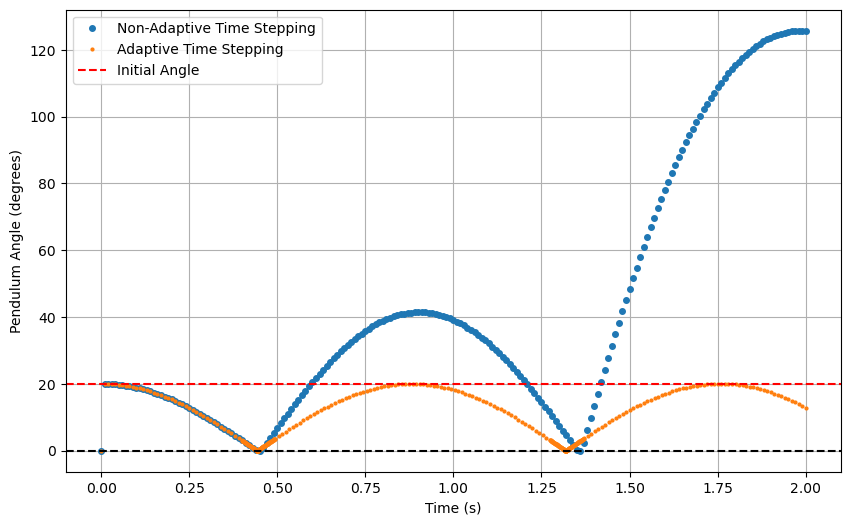

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(results_non_adaptive['time'], np.rad2deg(results_non_adaptive['theta']), label="Non-Adaptive Time Stepping", marker="o", markersize=4, linestyle="None")
plt.plot(results_adaptive['time'], np.rad2deg(results_adaptive['theta']), label="Adaptive Time Stepping", marker="o", markersize=2, linestyle="None")   
plt.axhline(20, color="r", linestyle="--", label="Initial Angle")
plt.axhline(0, color="k", linestyle="--")
plt.xlabel("Time (s)")
plt.ylabel("Pendulum Angle (degrees)")
plt.legend()
plt.grid()

We can see that for non-adative time stepping, the energy is not conserved, since the the pendulum reaches a greater maximum angle after contact than before.

This means, that the energy which is added by the contact model (due to penetration) is too high. A reason for this is the time discretization error, which leads to an overestimation of the penetration depth when using large time steps.

When using adaptive time stepping, the time step is reduced around the contact event, leading to a more accurate estimation of the penetration depth and thus better energy conservation.

## Compliant Pendulum Contact

In [57]:
res_compliant = run_simulation(config=compliant_config,
                               use_adaptive_time_stepping=True)

In [58]:
animate(res_compliant)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 15}}, …

We can identify a minimal penetration of the compliant pendulum into the wall, which is expected due to the lower stiffness of the pendulum material. Further, we can see that the pendulum shows a elastic deformation at the contact point, which is also expected due to the compliant material properties.

The less stiff the pendulum material is, the less appropriate is the rigid body approximation for the pendulum angle.
It can be observed that the pendulum starts rod and head starts to oscillate.